In [20]:
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use("ggplot")

TARGET_SR = 22050

In [21]:
file_path = "query_files/double_bass_stereo.aiff"

y_raw, sr_raw = librosa.load(file_path, sr=None)

print("Original Sample Rate:", sr_raw)
print("Original Duration:", len(y_raw)/sr_raw, "seconds")

Original Sample Rate: 44100
Original Duration: 2.9831519274376417 seconds


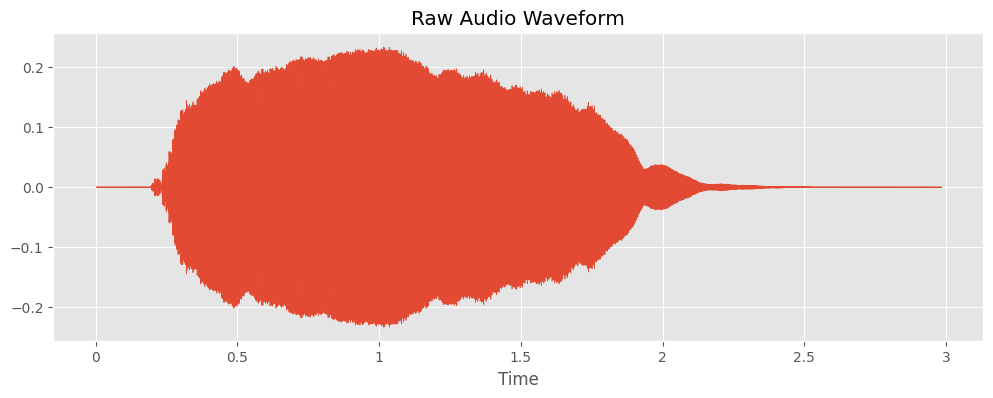

In [22]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(y_raw, sr=sr_raw)
plt.title("Raw Audio Waveform")
plt.show()

In [23]:
if sr_raw != TARGET_SR:
    y_resampled = librosa.resample(y_raw, orig_sr=sr_raw, target_sr=TARGET_SR)
else:
    y_resampled = y_raw

print("After Resample Sample Rate:", TARGET_SR)
print("Duration After Resample:", len(y_resampled)/TARGET_SR)

After Resample Sample Rate: 22050
Duration After Resample: 2.983174603174603


In [24]:
y_trimmed, _ = librosa.effects.trim(y_resampled, top_db=20)

print("Duration After Trim:", len(y_trimmed)/TARGET_SR)

Duration After Trim: 1.8575963718820863


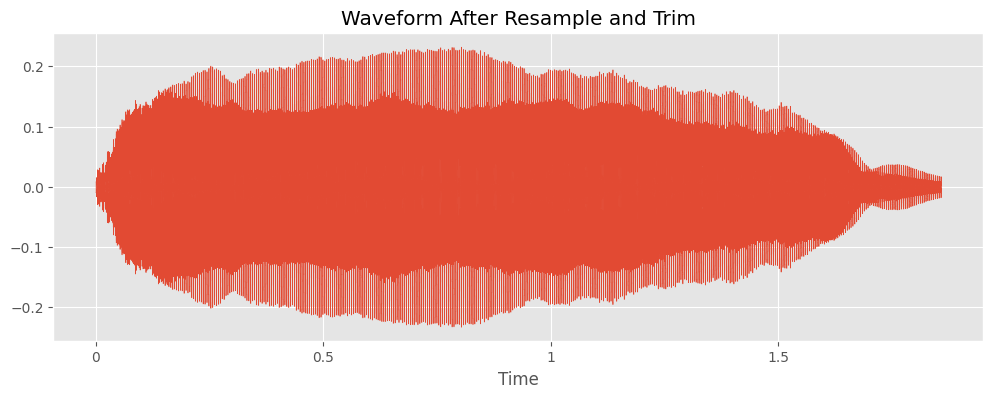

In [25]:
plt.figure(figsize=(12,4))
librosa.display.waveshow(y_trimmed, sr=TARGET_SR)
plt.title("Waveform After Resample and Trim")
plt.show()


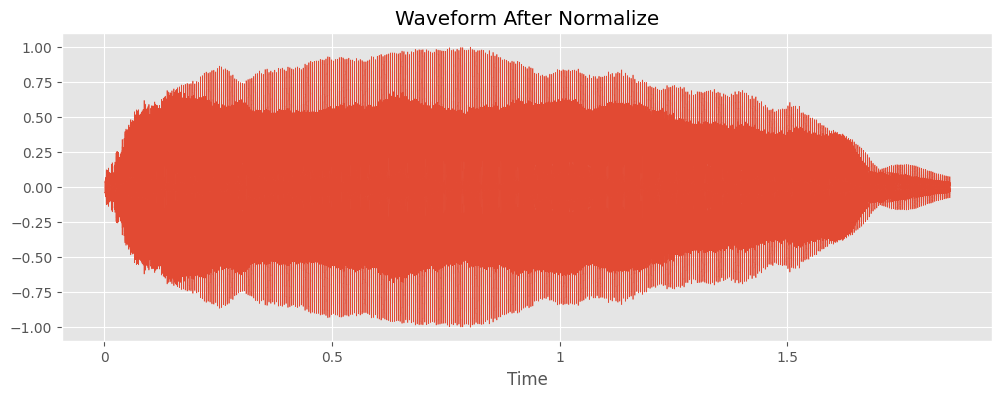

In [26]:
y_processed = librosa.util.normalize(y_trimmed)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y_processed, sr=TARGET_SR)
plt.title("Waveform After Normalize")
plt.show()

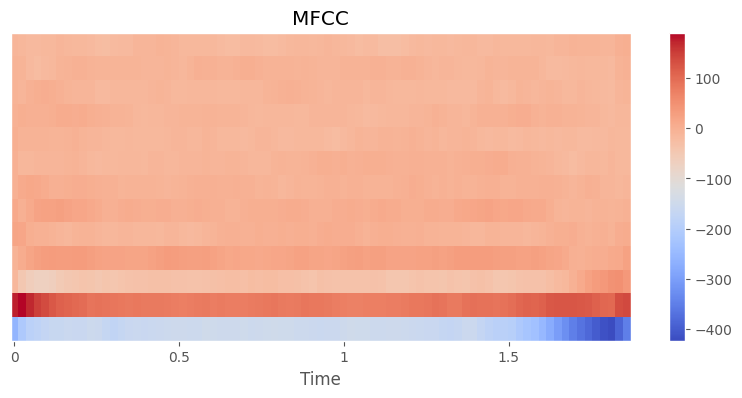

In [27]:
mfcc = librosa.feature.mfcc(y=y_processed, sr=TARGET_SR, n_mfcc=13)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis="time")
plt.colorbar()
plt.title("MFCC")
plt.show()

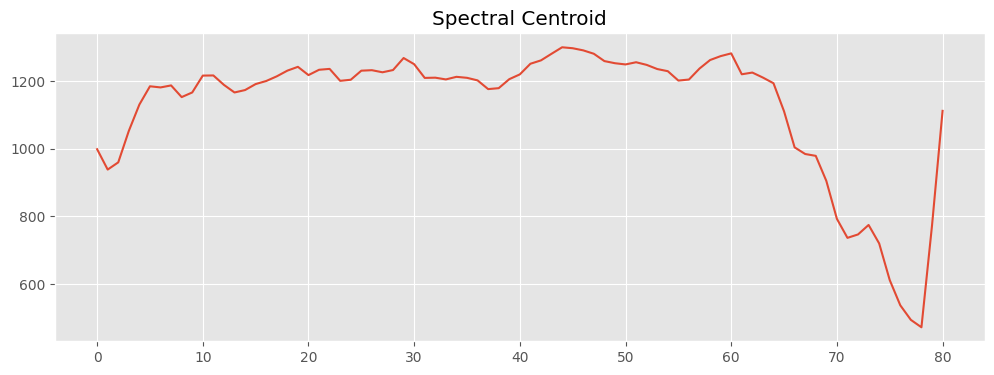

In [28]:
centroid = librosa.feature.spectral_centroid(y=y_processed, sr=TARGET_SR)
bandwidth = librosa.feature.spectral_bandwidth(y=y_processed, sr=TARGET_SR)
rolloff = librosa.feature.spectral_rolloff(y=y_processed, sr=TARGET_SR)

plt.figure(figsize=(12,4))
plt.plot(centroid.T)
plt.title("Spectral Centroid")
plt.show()

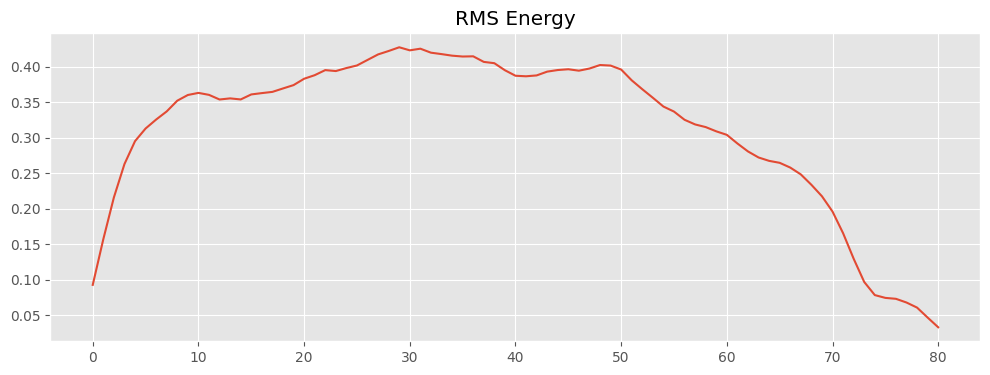

In [29]:
rms = librosa.feature.rms(y=y_processed)
zcr = librosa.feature.zero_crossing_rate(y_processed)

plt.figure(figsize=(12,4))
plt.plot(rms.T)
plt.title("RMS Energy")
plt.show()

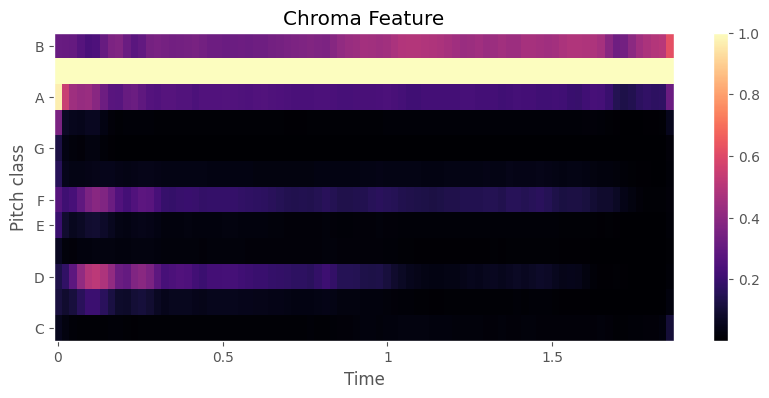

In [30]:
chroma = librosa.feature.chroma_stft(y=y_processed, sr=TARGET_SR)

plt.figure(figsize=(10,4))
librosa.display.specshow(chroma, x_axis="time", y_axis="chroma")
plt.colorbar()
plt.title("Chroma Feature")
plt.show()

In [31]:
features = []

# MFCC mean
features.extend(np.mean(mfcc, axis=1))

# MFCC std
features.extend(np.std(mfcc, axis=1))

# Spectral features
for feature in [centroid, bandwidth, rolloff]:
    features.append(np.mean(feature))
    features.append(np.std(feature))

# RMS
features.append(np.mean(rms))
features.append(np.std(rms))

# Chroma mean
features.extend(np.mean(chroma, axis=1))

# Chroma std
features.extend(np.std(chroma, axis=1))

# ZCR
features.append(np.mean(zcr))
features.append(np.std(zcr))

query_vector = np.array(features).reshape(1, -1)

print("Feature Vector Shape:", query_vector.shape)


Feature Vector Shape: (1, 60)


In [32]:
metadata = pd.read_csv("../metadata.csv")

print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (500, 63)


,id,file_name,instrument,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,...,chroma_5_std,chroma_6_std,chroma_7_std,chroma_8_std,chroma_9_std,chroma_10_std,chroma_11_std,chroma_12_std,zcr_mean,zcr_std
0,1,banjo_001.aiff,banjo,-491.672150,97.776176,42.331360,26.155785,13.627524,8.323347,6.540183,...,0.235170,0.199440,0.017022,0.139882,0.174440,0.158416,0.154817,0.165816,0.020790,0.016112
1,2,banjo_002.aiff,banjo,-305.221069,153.741409,-18.697783,-1.106865,0.767700,-6.779652,-10.171721,...,0.161652,0.106966,0.090105,0.140943,0.236574,0.254516,0.043663,0.036752,0.052677,0.014116
2,3,banjo_003.aiff,banjo,-372.708221,143.332977,-2.862892,-1.141588,3.347976,1.067092,-0.164358,...,0.004542,0.160346,0.142055,0.151787,0.216008,0.283311,0.079804,0.077421,0.055393,0.020078
3,4,banjo_004.aiff,banjo,-287.481018,70.810905,6.046579,15.216092,0.831419,-16.651762,0.087215,...,0.139025,0.072284,0.091186,0.130229,0.174681,0.064706,0.033508,0.012846,0.113867,0.037738
4,5,banjo_005.aiff,banjo,-355.495453,89.723137,10.236101,13.602125,4.044679,7.407011,-2.055372,...,0.307678,0.129458,0.143305,0.112655,0.116532,0.146425,0.077716,0.091861,0.040059,0.016054


In [33]:
feature_columns = metadata.columns[3:]
dataset_vectors = metadata[feature_columns].values

similarities = cosine_similarity(query_vector, dataset_vectors)[0]

metadata["similarity"] = similarities

print("Query vector shape:", query_vector.shape)
print("Dataset vector shape:", dataset_vectors.shape)
print("\nSimilarity statistics:")
print("Max similarity:", np.max(similarities))
print("Min similarity:", np.min(similarities))
print("Mean similarity:", np.mean(similarities))


Query vector shape: (1, 60)
Dataset vector shape: (500, 60)

Similarity statistics:
Max similarity: 0.9960441248387474
Min similarity: 0.621190797335164
Mean similarity: 0.8865702102926386


In [34]:
sample_vector = dataset_vectors[0].reshape(1, -1)

manual_cosine = cosine_similarity(query_vector, sample_vector)[0][0]

print("File name:", metadata.iloc[0]["file_name"])
print("Instrument:", metadata.iloc[0]["instrument"])
print("Cosine similarity (manual):", manual_cosine)

File name: banjo_001.aiff
Instrument: banjo
Cosine similarity (manual): 0.8775995803591707


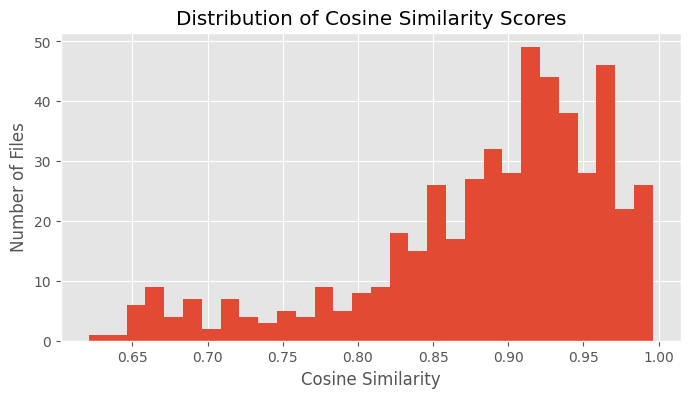

In [35]:
plt.figure(figsize=(8,4))
plt.hist(similarities, bins=30)
plt.title("Distribution of Cosine Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Files")
plt.show()

In [36]:
top5 = metadata.sort_values(by="similarity", ascending=False).head(5)

top5[["file_name", "instrument", "similarity"]]

,file_name,instrument,similarity
51,banjo_052.aiff,banjo,0.996044
55,banjo_056.aiff,banjo,0.995590
17,banjo_018.aiff,banjo,0.995522
4,banjo_005.aiff,banjo,0.995167
44,banjo_045.aiff,banjo,0.993391


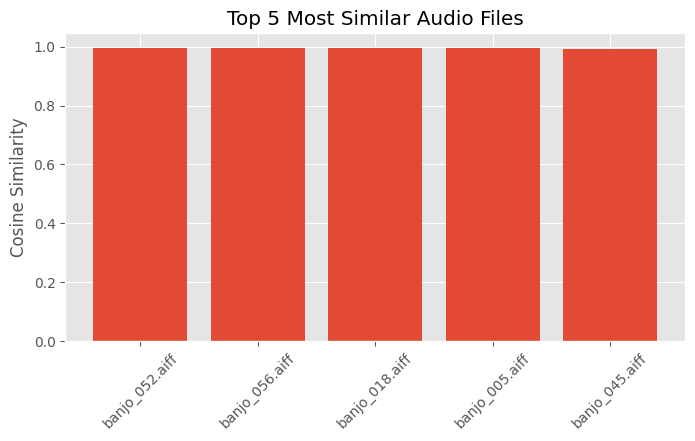

In [37]:
plt.figure(figsize=(8,4))
plt.bar(top5["file_name"], top5["similarity"])
plt.xticks(rotation=45)
plt.title("Top 5 Most Similar Audio Files")
plt.ylabel("Cosine Similarity")
plt.show()